In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy 
from astropy.io import fits, ascii
from astropy.table import Table
import astroquery 
import glob
import os
from astroquery.mast import Observations, Mast, MastMissions, MastMissionsClass, Catalogs
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.xmatch import XMatch
import k3d
from astropy.timeseries import BoxLeastSquares
from astroquery.sdss import SDSS
import fitsio
import pandas as pd

Could not import regions, which is required for some of the functionalities of this module.


In [10]:
params = {'axes.labelsize': 12, 'xtick.labelsize': 12, 'ytick.labelsize': 12, 
          'text.usetex': False, 'lines.linewidth': 1,
          'axes.titlesize': 18, 'font.family': 'serif', 'font.size': 12}
plt.rcParams.update(params)

In [5]:
fits = fitsio.read('allStar-dr17-synspec_rev1.fits', ext = 1)

In [6]:
# lets just choose 50k stars from apogee to get the idea
ls = fits[1:50000].tolist()

In [7]:
names = fits.dtype.names

In [8]:
apogee= pd.DataFrame(ls, columns = names)

Text(0, 0.5, '[Mg/Fe]')

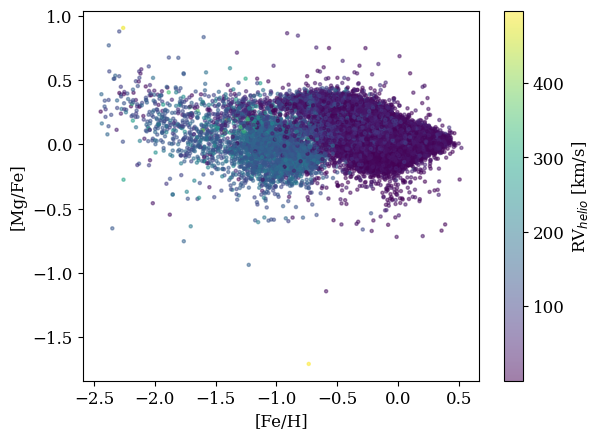

In [11]:
plt.scatter(apogee['FE_H'], apogee['MG_FE'], s = 5, alpha = 0.5, c = np.abs(apogee['VHELIO_AVG']), cmap='viridis')
plt.colorbar(label = r'RV$_{helio}$ [km/s]')
plt.xlabel("[Fe/H]")
plt.ylabel("[Mg/Fe]")

In [12]:
# from https://exoplanetarchive.ipac.caltech.edu/docs/data.html transiting planets table
transiting_exo = ascii.read('./data/TD_2026.04.27_13.36.06.csv')

In [13]:
# search for Gaia counterparts
target_table = Table()
target_table['pl_name'] = transiting_exo['pl_name'].astype(str)
target_table['ra'] = transiting_exo['ra'].astype(float)
target_table['dec'] = transiting_exo['dec'].astype(float)

In [15]:
results = XMatch.query(
    cat1=target_table,
    cat2='vizier:III/284/allstars',
    max_distance=1.0 * u.arcsec,    # adjust as needed
    colRA1='ra',
    colDec1='dec'
)

In [ ]:
idx_list=[]
for i, r in enumerate(results): 
    idx = np.where(r['pl_name'] == target_table['pl_name'])[0]
    idx_list.append(idx[0])
    

    


In [28]:
duplicates

array([  162,   174,   199, ..., 34734, 34839, 35572], shape=(1079,))

In [ ]:
results['target_idx'] = idx_list

IndexError: index 14700 is out of bounds for axis 0 with size 11243

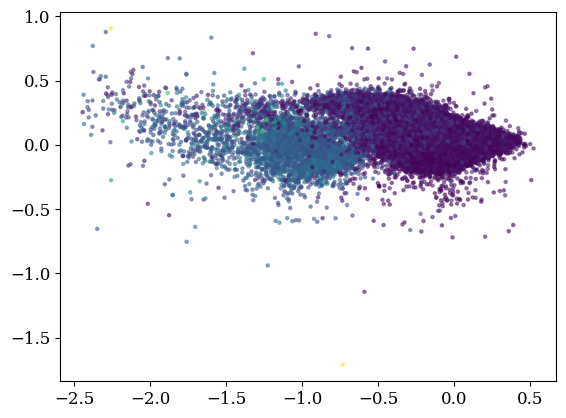

In [ ]:
plt.scatter(apogee['FE_H'], apogee['MG_FE'], s = 5, alpha = 0.5, c = np.abs(apogee['VHELIO_AVG']), cmap='viridis')


plt.scatter(results['[Fe/H]'][results['target_idx']], matched_apogee['MG_FE'], s = 10, alpha = 0.8, c = 'r', label = 'Matched Stars')
plt.colorbar(label = r'RV$_{helio}$ [km/s]')
plt.xlabel("[Fe/H]")
plt.ylabel("[Mg/Fe]")

In [ ]:
ls = fits[:10].tolist() 

In [ ]:
apogee = np.array(fits.tolist()) 

In [ ]:
Observations.download_file('mast:SDSS/apogee/allStar-dr17-synspec_rev1.fits')

In [ ]:
# from https://exoplanetarchive.ipac.caltech.edu/docs/data.html transiting planets table
transiting_exo = ascii.read('./data/TD_2026.04.27_13.36.06.csv')

In [ ]:
header = fitsio.read_header('allStar-dr17-synspec_rev1.fits', ext=1)

In [ ]:
header_list = [ (key) for key in header.keys() ]

In [ ]:
fits = fitsio.read('allStar-dr17-synspec_rev1.fits', ext = 1)

In [ ]:
apogee = np.array(fits)

In [ ]:
array = apogee[0]

In [ ]:
array

In [ ]:
fits = fitsio.read('allStar-dr17-synspec_rev1.fits', ext = 1)
apogee_array = []
for row in fits[1:]:
    apogee_array.append(row)

In [ ]:
apogee = Table(fits)

In [ ]:
apogee = Table(apogee_array, names = header_list)

In [ ]:
apogee=[]
with fits.open('allStar-dr17-synspec_rev1.fits', memmap=True) as hdul:
    header = hdul[1].header
    

In [ ]:
# from https://exoplanetarchive.ipac.caltech.edu/docs/data.html transiting planets table
transiting_exo = ascii.read('./data/TD_2026.04.27_13.36.06.csv')

In [ ]:
coords = SkyCoord(ra = transiting_exo['ra']*u.degree, dec = transiting_exo['dec']*u.degree, frame = 'icrs')
#m = np.abs(((coords.galactic).b).degree) < 10
targets = transiting_exo

In [ ]:
# search for Gaia counterparts
target_table = Table()
target_table['pl_name'] = targets['pl_name'].astype(str)
target_table['ra'] = targets['ra'].astype(float)
target_table['dec'] = targets['dec'].astype(float)

In [ ]:
results = XMatch.query(
    cat1=target_table,
    cat2='vizier:I/355/gaiadr3',
    max_distance=2.0 * u.arcsec,    # adjust as needed
    colRA1='ra',
    colDec1='dec'
)

In [ ]:
idx_list=[]
for i, r in enumerate(results): 
    idx = np.where(r['pl_name'] == target_table['pl_name'])[0]
    idx_list.append(idx[0])

In [ ]:
distance = 1/(results['Plx']*1E3)

In [ ]:
np.max(distance)

In [ ]:
distance = 1/(results['Plx']*1E3)
z = distance* (np.cos(((coords.galactic).b).degree)[idx_list])

In [ ]:
from scipy.stats import gaussian_kde

In [ ]:
m = (targets['pl_rade'][idx_list] > 1.5) & (targets['pl_rade'][idx_list] < 5) & (results['[Fe/H]'] > -2) & (results['[Fe/H]'] < 1) 
plt.hist(results['[Fe/H]'][m], color = 'green',edgecolor = 'green', alpha = 0.8, histtype='step', label = f"Super-Earths: [Fe/H] = {np.mean(results['[Fe/H]'][m]):.2f}")
#plt.axvline(np.mean(results['[Fe/H]'][m]), color = 'green', linestyle = '--')
m = (targets['pl_rade'][idx_list] > 5) & (results['[Fe/H]'] > -2) & (results['[Fe/H]'] < 1) 
plt.hist(results['[Fe/H]'][m], color = 'orange', edgecolor = 'orange',alpha = 0.8, histtype='step', label = f"Jupiters: [Fe/H] = {np.mean(results['[Fe/H]'][m]):.2f}")
#plt.axvline(np.mean(results['[Fe/H]'][m]), color = 'orange', linestyle = '--')
m = (targets['pl_rade'][idx_list] < 1.5) & (results['[Fe/H]'] > -2) & (results['[Fe/H]'] < 1) 
plt.hist(results['[Fe/H]'][m], color = 'brown', alpha = 0.8, edgecolor = 'brown',histtype='step', label = f"Terrestrials: [Fe/H] = {np.mean(results['[Fe/H]'][m]):.2f}")
#plt.axvline(np.mean(results['[Fe/H]'][m]), color = 'brown', linestyle = '--')
m = (targets['pl_rade'][idx_list] > 5) & (targets['pl_rade'][idx_list] < 10)& (results['[Fe/H]'] > -2) & (results['[Fe/H]'] < 1) 
plt.hist(results['[Fe/H]'][m], color = 'blue', edgecolor = 'blue',alpha = 0.8, histtype='step', label = f"Neptunes: [Fe/H] = {np.mean(results['[Fe/H]'][m]):.2f}")
#plt.axvline(np.mean(results['[Fe/H]'][m]), color = 'blue', linestyle = '--')
plt.yscale('log')
plt.legend()
plt.xlabel("[Fe/H]")
plt.ylabel("N")

In [ ]:
plt.axhspan(np.log10(np.min(targets['pl_rade'][idx_list])), np.log10(1.5), alpha = 0.2, color = 'brown')
plt.text(-3.9, -0.2, "Terrestrials", color = 'k')
plt.axhspan(np.log10(1.5), np.log10(5), alpha = 0.2, color = 'green')
plt.text(-3.9, 0.4, "Super-Earths", color = 'k')
plt.axhspan(np.log10(5), np.log10(10), alpha = 0.2, color = 'blue')
plt.text(-3.9, 0.8, "Neptunes", color = 'k')
plt.axhspan(np.log10(10), np.log10(np.max(targets['pl_rade'][idx_list])), alpha = 0.2, color = 'orange')
plt.text(-3.9, 2, "Jupiters", color = 'k')
valid = np.isfinite(results['[Fe/H]']) & np.isfinite(targets['pl_rade'][idx_list])
x = results['[Fe/H]'][valid]
y = np.log10(targets['pl_rade'][idx_list][valid])
plt.hexbin(x, y, gridsize=80, cmap='viridis', mincnt=1, bins='log')
plt.colorbar(label='log N')
plt.xlabel('[Fe/H]', fontsize = 12)
plt.ylabel(r'$\log R_p$ [$R_\oplus$]', fontsize = 12)

In [ ]:

plt.yscale('log')
plt.xlabel('[Fe/H]', fontsize = 14)
plt.ylabel(r'R$_{\oplus}$', fontsize = 14)
plt.axhspan(np.min(targets['pl_rade'][idx_list]), 1.5, alpha = 0.2, color = 'brown')
plt.text(-3.9, 0.6, "Terrestrials", color = 'brown')
plt.axhspan(1.5, 5, alpha = 0.2, color = 'green')
plt.text(-3.9, 2.3, "Super-Earths/Mini-Neptunes", color = 'green')
plt.axhspan(5, 10, alpha = 0.2, color = 'blue')
plt.text(-3.9, 6, "Neptunes", color = 'blue')
plt.axhspan(10, np.max(targets['pl_rade'][idx_list]), alpha = 0.2, color = 'orange')
plt.text(-3.9, 100, "Jupiters", color = 'orange')
plt.scatter(results['[Fe/H]'], targets['pl_rade'][idx_list], color = 'k', alpha = 0.3, s = 5)

In [ ]:
plt.scatter(results['[Fe/H]'], targets['pl_rade'][idx_list], c = np.log10(z), cmap = 'viridis', alpha = 0.3, s = 1)
plt.yscale('log')
plt.colorbar()

In [ ]:
associated_star = [False] * len(targets)
targets['lumclass'] = ['      '] * len(targets)
targets['plx'] = [np.nan]*len(targets)
targets['e_plx'] = [np.nan]*len(targets)
targets['Teff'] = [np.nan]*len(targets)
targets['e_Teff']=[np.nan]*len(targets)
for i,t in enumerate(targets): 
    target_name = t['pl_name']
    print(f"Iteration #{i}: {target_name}...")
    search_radius_deg = 0.2
    try:
        catalogTIC = Catalogs.query_object(target_name, radius=search_radius_deg, catalog="TIC")
    except Exception as e: 
        print("Name could not be resolved.")
    where_closest = np.argmin(catalogTIC['dstArcSec'])
    distance = catalogTIC['dstArcSec'][where_closest]
    if(distance < 1):
        print("Match found")
        associated_star[i] = True 
        if(np.ma.is_masked(catalogTIC['lumclass'][where_closest])):
            targets['lumclass'][i] = 'N/A'
        else: 
            targets['lumclass'][i] = catalogTIC['lumclass'][where_closest]
        targets['lumclass'][i] = targets['lumclass'][i].strip()
        targets['plx'][i] = catalogTIC['plx'][where_closest]
        targets['e_plx'][i] = catalogTIC['e_plx'][where_closest]
        targets['Teff'][i] = catalogTIC['Teff'][where_closest] 
        targets['e_Teff'][i] = catalogTIC['e_Teff'][where_closest]

In [ ]:
catalogTIC

In [ ]:
tessmatches = targets[associated_star]

In [ ]:
m = ~np.isnan(tessmatches['plx'])
tessmatches=tessmatches[m]

In [ ]:
tessmatches['distance']=1/tessmatches['plx']
tessmatches['distanceerr'] = 1/tessmatches['e_plx']

In [ ]:
def distance(x1,y1,z1, x2,y2,z2): 
    return np.sqrt((x1-x2)**2 + (y1-y2)**2 + (z1-z2)**2)

In [ ]:
coords = SkyCoord(ra=tessmatches['ra']*u.degree, dec = tessmatches['dec']*u.degree, frame = 'icrs')
tessmatches['l'] = ((coords.galactic).l).degree
tessmatches['b'] = ((coords.galactic).b).degree
X_sun = tessmatches['distance']*np.cos(tessmatches['b'])*np.cos(tessmatches['l'])
Y_sun = tessmatches['distance']*np.cos(tessmatches['b'])*np.sin(tessmatches['l'])
Z_sun = tessmatches['distance']*np.sin(tessmatches['l'])

X_gc = 8E3 # parsecs 
Y_gc = 0 
Z_gc = 0
gal_dist = distance(X_sun, Y_sun, Z_sun, X_gc, Y_gc, Z_gc)

In [ ]:
def polynomial(x, a,b,c,d): 
    return a*x**3 + b * x**2 + c*x + d 

In [ ]:
from scipy.optimize import curve_fit

In [ ]:
plt.hist(Z_sun)

In [ ]:
xval = tessmatches['pl_trandur']
xerr = tessmatches['pl_trandurerr1']
yval = tessmatches['pl_orbeccen']
yerr = tessmatches['pl_orbeccenerr1']
plt.errorbar(xval, yval,  xerr = xerr, yerr = yerr, fmt = 'o', color = 'k')
popt, pcov = curve_fit(polynomial, xval, yval)
x = np.linspace(np.min(xval), np.max(xval), 100)
fit = polynomial(x, popt[0], popt[1], popt[2], popt[3])
plt.plot(x, fit, color = 'r', linestyle = '--')
fit_lower = polynomial(x, popt[0], popt[1], popt[2], popt[3])
#plt.yscale('log')

In [ ]:
pcov

In [ ]:
popt

In [ ]:
plt.errorbar(tessmatches['pl_orbper'], tessmatches['pl_rade'], xerr = tessmatches['pl_orbpererr1'], yerr = tessmatches['pl_radeerr1'], fmt = '.')

In [ ]:
# convert from galactic coords which are based around the sun to coords that are 
# centered around galactic center 

# start by converting to sun-centric cartesian 
b = targetlist['b']
l = targetlist['l']
X_sun = targetlist['dist']*np.cos(b)*np.cos(l)
Y_sun = targetlist['dist']*np.cos(b)*np.sin(l)
Z_sun = targetlist['dist']*np.sin(l)

# now let's find the distance between this point and the galactic center! 
# since we're just fuckin around, let's assume our sun lies perfeclty in
# the galactic plane so Z_gc = 0 
# then, X_gc is the only thing that chances (it lies ~ 8 kpc away)

X_gc = 8E3 # parsecs 
Y_gc = 0 
Z_gc = 0



gal_dist = distance(X_sun, Y_sun, Z_sun, X_gc, Y_gc, Z_gc) # pc 

In [ ]:
np.nanmax(tessmatches['distance'])

In [ ]:
catalogTIC = Catalogs.query_object("CoRoT-16 b", radius=0.2, catalog="TIC")

In [ ]:
type(catalogTIC['lumclass'][1]) 

In [ ]:
np.ma.is_masked(catalogTIC['lumclass'][0])

In [ ]:
catalogTIC[np.argmin(catalogTIC['dstArcSec'])]

In [ ]:
target_name = table['pl_name'][0]
search_radius_deg = 0.2
catalogTIC = Catalogs.query_object(target_name, radius=search_radius_deg, catalog="TIC")
where_closest = np.argmin(catalogTIC['dstArcSec'])
print("Closest TIC ID to %s: TIC %s, separation of %f arcsec. and a TESS mag. of %f"% \
      (target_name, catalogTIC['ID'][where_closest], catalogTIC['dstArcSec'][where_closest],\
      catalogTIC['Tmag'][where_closest]))

Looking at TESS sector 44. Read more here: https://tess.mit.edu/observations/sector-44/

In [ ]:
def query_tess_sectors(sectornum): 
    table = Observations.query_criteria(provenance_name="TESS-SPOC",sequence_number=sectornum)
    return table

In [ ]:
sectorlist = [44]
obs_table = []
for i, num in enumerate(sectorlist):
    print(f"Querying sector {num}")
    if i ==0: 
        obs = query_tess_sectors(num)
        obs_table = obs
    else: 
        obs = query_tess_sectors(num)
        np.vstack([obs_table, obs])

In [ ]:
coords = SkyCoord(ra = obs_table['s_ra']*u.degree, dec = obs_table['s_dec']*u.degree, frame ='icrs')
coords_gal = coords.galactic
obs_table['l'] = (coords_gal.l).degree
obs_table['b'] = (coords_gal.b).degree
m = np.abs(obs_table['b']) < 2
targets = obs_table[m]

In [ ]:
targets

In [ ]:
#download data
data = Observations.get_product_list(targets)
download_lc = Observations.download_products(data)

In [ ]:
table = ascii.read('./data/TD_2026.04.27_13.36.06.csv')

In [ ]:
table

In [ ]:
folder_list = glob.glob('mastDownload/*/*')[:5]

file_list = []
for f in folder_list: 
    files = glob.glob(os.path.join(f, "*"))
    all_time = []
    all_flux = []
    all_flux_err=[]
    for i, file in enumerate(files): 
        if(file[-7:-5] == 'lc'):
            hdu_list=fits.open(file)
            data = Table(hdu_list[1].data)
            mask = (data['QUALITY'] == 0) & (~np.isnan(data['PDCSAP_FLUX']))
            data_filtered = data[mask]
            current_time = data_filtered['TIME'].tolist()
            current_flux = data_filtered['PDCSAP_FLUX']/(np.median(data_filtered['PDCSAP_FLUX'])).tolist()
            current_flux_error = data_filtered['PDCSAP_FLUX_ERR']/(np.median(data_filtered['PDCSAP_FLUX_ERR'])).tolist()
            all_time.extend(current_time)
            all_flux.extend(current_flux)
            all_flux_err.extend(current_flux_error)
            # plotting
            figure, ax = plt.subplots(1, 2)
            figure.set_figwidth(11)
            figure.set_figheight(5)
            figure.tight_layout(pad=3.0)
            plt.subplot(1, 2, 2)
            model = BoxLeastSquares(np.array(current_time) * u.day, np.array(current_flux), dy= np.array(current_flux_error))
            periodogram = model.autopower(0.05 * u.day, minimum_period=0.1, maximum_period=12, oversample=1000)
            plt.plot(periodogram.period, periodogram.power)
            plt.xlabel('Period (day)')
            plt.ylabel('Power')
            plt.subplot(1, 2, 1)
            plt.scatter(current_time, current_flux, s = 0.1)
            plt.xlabel('Julian Date')
            plt.ylabel('Normalized Flux')
            plt.show()

In [ ]:
file = glob.glob(f"{folder_list[0]}/*")[1]
hdu_list = fits.open(file)
data = Table(hdu_list[1].data)

In [ ]:
data

In [ ]:
targetobj = file_list[0]
hdu_list=fits.open(targetobj)
data = Table(hdu_list[1].data)

In [ ]:
# search for Gaia counterparts
target_table = Table()
target_table['tess_name'] = targetlist['target_name'].astype(str)
target_table['ra'] = targetlist['s_ra'].astype(float)
target_table['dec'] = targetlist['s_dec'].astype(float)

In [ ]:
results = XMatch.query(
    cat1=target_table,
    cat2='vizier:I/355/gaiadr3',
    max_distance=1.0 * u.arcsec,    # adjust as needed
    colRA1='ra',
    colDec1='dec'
)

In [ ]:
orig_name = np.asarray(target_table['tess_name'])
matches_name = [str(name).strip() for name in results['tess_name']]
dist = [np.nan]*len(targetlist)
dist_err = [np.nan]*len(targetlist)
for i, mname in enumerate(matches_name): 
    idx = np.where(mname == orig_name)[0]
    if(len(idx) > 0): 
        dist[idx[0]] = 1/(results['Plx'][i]*1E3)
        dist_err[idx[0]] = 1/(results['e_Plx'][i]*1E3)
targetlist['dist'] = dist
targetlist['e_dist'] = dist_err

In [ ]:
# remove sources we couldn't find a distance for
m = ~np.isnan(targetlist['dist'])
targetlist=targetlist[m]

In [ ]:
# now lets find each observation's distance from the galactic center 

In [ ]:
def distance(x1,y1,z1, x2,y2,z2): 
    return np.sqrt((x1-x2)**2 + (y1-y2)**2 + (z1-z2)**2)

In [ ]:
# convert from galactic coords which are based around the sun to coords that are 
# centered around galactic center 

# start by converting to sun-centric cartesian 
b = targetlist['b']
l = targetlist['l']
X_sun = targetlist['dist']*np.cos(b)*np.cos(l)
Y_sun = targetlist['dist']*np.cos(b)*np.sin(l)
Z_sun = targetlist['dist']*np.sin(l)

# now let's find the distance between this point and the galactic center! 
# since we're just fuckin around, let's assume our sun lies perfeclty in
# the galactic plane so Z_gc = 0 
# then, X_gc is the only thing that chances (it lies ~ 8 kpc away)

X_gc = 8E3 # parsecs 
Y_gc = 0 
Z_gc = 0



gal_dist = distance(X_sun, Y_sun, Z_sun, X_gc, Y_gc, Z_gc) # pc 

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(10,4))
ax.hist(gal_dist, bins = 100, color = 'k')
ax.set_yscale('log')
ax.axvline(x=8000, label = r'R$_{Earth}$')
ax.legend(frameon=False, fontsize = 14)
ax.set_xlabel("Distance from galactic center (pc)", fontsize = 12)
ax.set_ylabel("N", fontsize = 12)

In [ ]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize = (6,6))
X = X_sun + X_gc 
theta = np.tan(Y_sun/X)
ax.scatter(theta, np.log10(gal_dist), color = 'k', s =1)
ax.scatter(1000, 0, color = 'orange', marker = 'X', s=100)
ax.set_thetalim(-np.pi/2,np.pi/2)
#ax.set_rlim(0, 8500)

In [ ]:
np.pi/2

In [ ]:
positions = [[x,y,z] for x,y,z in zip(X_sun, Y_sun, Z_sun)]

In [ ]:
# lets look at our distance spread real quick!! 
plot = k3d.plot()
plt_points = k3d.points(positions= positions,point_size=0.001, color=0x000000)
plot += plt_points
plot.display()

In [ ]:
gal_dist

In [ ]:
coord = SkyCoord(ra=target['s_ra'], dec=target['s_dec'], unit=(u.degree, u.degree), frame='icrs')
j = Gaia.cone_search_async(coord, radius=u.Quantity(1.0, u.deg))
r = j.get_results()

In [ ]:
target

In [ ]:
r[0]

In [ ]:
data = Observations.get_product_list(obsTable[0])

In [ ]:
download_lc = Observations.download_products(data)

In [ ]:
files = glob.glob('mastDownload/HLSP/hlsp_tess-spoc_tess_phot_0000000264247117-s0026_tess_v1_tp/*')

In [ ]:
hdu_list = fits.open(files[0])
data1= Table(hdu_list[1].data)

In [ ]:
data1